In [ ]:
from pycoingecko import CoinGeckoAPI
import pandas as pd
import matplotlib.pyplot as plt

cg = CoinGeckoAPI()

top_coins = cg.get_coins_markets(vs_currency='usd', per_page=5, page=1)

df_api = pd.DataFrame(top_coins)[['market_cap_rank', 'id', 'symbol', 'name', 'current_price', 'market_cap']]

df_api = df_api.sort_values(by='market_cap_rank')
print("CoinGecko API:")
print(df_api)

🔌 ข้อมูลจาก CoinGecko API:
   market_cap_rank           id symbol      name  current_price     market_cap
0                1      bitcoin    btc   Bitcoin      117838.00  2343824201276
1                2     ethereum    eth  Ethereum        2988.88   361116792339
2                3       ripple    xrp       XRP           2.83   166693244369
3                4       tether   usdt    Tether           1.00   159096792123
4                5  binancecoin    bnb       BNB         691.85   101061762145


In [4]:
import requests

url = 'https://api.coingecko.com/api/v3/coins/markets'
params = {
    'vs_currency': 'usd',
    'order': 'market_cap_desc',
    'per_page': 5,
    'page': 1
}
response = requests.get(url, params=params)
data = response.json()


df_http = pd.DataFrame(data)[['market_cap_rank', 'id', 'symbol', 'name', 'current_price', 'market_cap']]
df_http = df_http.sort_values(by='market_cap_rank')
print("\nHTTP Request:")
print(df_http)


HTTP Request:
   market_cap_rank           id symbol      name  current_price     market_cap
0                1      bitcoin    btc   Bitcoin      117869.00  2343824201276
1                2     ethereum    eth  Ethereum        2990.19   361116792339
2                3       ripple    xrp       XRP           2.83   166693244369
3                4       tether   usdt    Tether           1.00   159096792123
4                5  binancecoin    bnb       BNB         692.22   101061762145


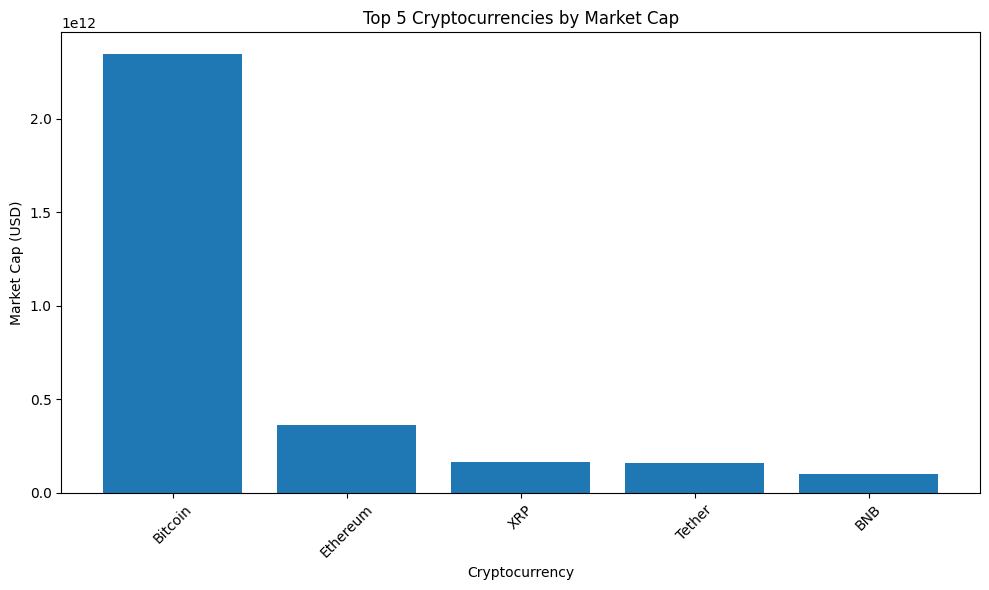

In [ ]:
df_plot = df_api.copy()

plt.figure(figsize=(10, 6))
plt.bar(df_plot['name'], df_plot['market_cap'])
plt.title('Top 5 Cryptocurrencies by Market Cap')
plt.xlabel('Cryptocurrency')
plt.ylabel('Market Cap (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()